In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from rudygrad.engine import Value
from rudygrad.nn import Neuron, Layer, MLP

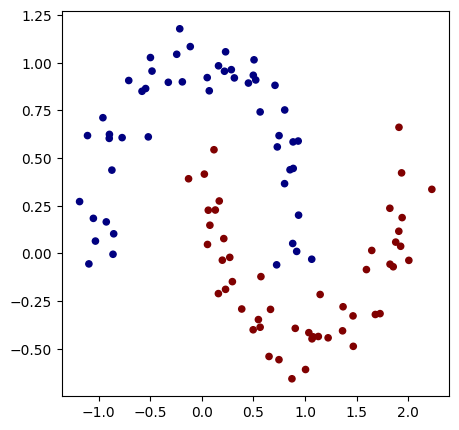

In [3]:
from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=100, noise=0.1)

y = y*2 - 1
plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=20, cmap='jet')

In [4]:
model = MLP(2, [16, 16, 1])
len(model.parameters())

337

In [5]:
def loss():
    inputs = [list(map(Value, xrow)) for xrow in X]

    scores = list(map(model, inputs))

    losses = [(1 + -yi*scorei).relu() for yi, scorei in zip(y, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))
    
    alpha = 0.0001
    reg_loss = alpha * sum((p*p for p in model.parameters()))
    total_loss = data_loss - reg_loss

    accuracy = [(yi > 0) == (scorei.data > 0 ) for yi, scorei in zip(y, scores)]
    return total_loss, sum(accuracy) / len(accuracy)

In [6]:
for k in range(100):
    # forward
    total_loss, acc = loss()

    # backward
    model.zero_grad()
    total_loss.backward()

    # update (sgd)
    learning_rate = 1.0 + 0.9*k/100
    for p in model.parameters():
        p.data -= learning_rate * p.grad
    
    if k % 1 == 0:
        print(f'step {k}, loss {total_loss}, accuracy {acc*100}%')

step 0, loss Value(data=0.5787779622552829), accuracy 79.0%
step 1, loss Value(data=0.34233842970720896), accuracy 81.0%
step 2, loss Value(data=0.2782217568832455), accuracy 87.0%
step 3, loss Value(data=0.2389475880265073), accuracy 89.0%
step 4, loss Value(data=0.22433900087889241), accuracy 92.0%
step 5, loss Value(data=0.213434273000921), accuracy 91.0%
step 6, loss Value(data=0.20450463894552745), accuracy 92.0%
step 7, loss Value(data=0.19671264545726838), accuracy 92.0%
step 8, loss Value(data=0.18959196100891776), accuracy 92.0%
step 9, loss Value(data=0.18287985745338992), accuracy 92.0%
step 10, loss Value(data=0.1764471833580778), accuracy 92.0%
step 11, loss Value(data=0.17025542321351703), accuracy 92.0%
step 12, loss Value(data=0.16430971895543273), accuracy 94.0%
step 13, loss Value(data=0.15862999762894636), accuracy 94.0%
step 14, loss Value(data=0.15321988742796736), accuracy 94.0%
step 15, loss Value(data=0.14807805291439474), accuracy 94.0%
step 16, loss Value(data

(-1.6573182075063593, 2.0926817924936407)

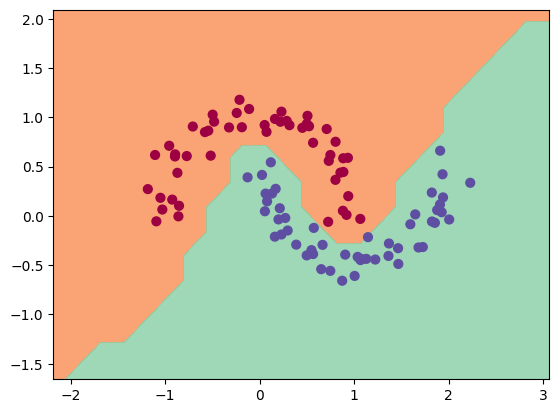

In [ ]:
h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))
Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())